> **Open in Google Colab.** The next cell installs `coptpy`. The bundled free license is size-limited but covers this case. Then run *Runtime > Run all*.


In [ ]:
# COPT Python API
%pip install -q coptpy


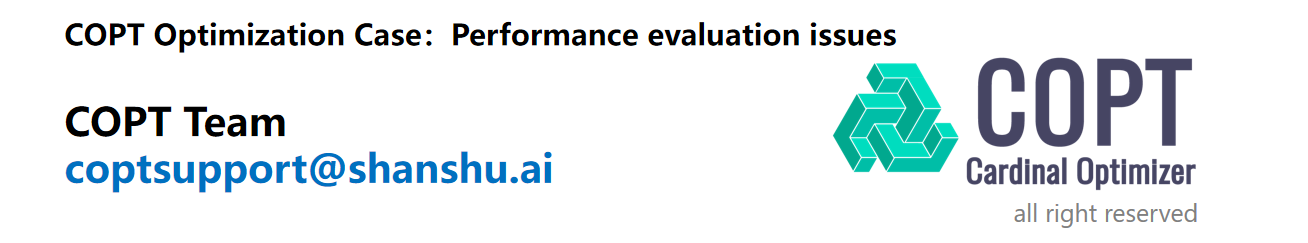

# Performance evaluation issues Code Implementation

## Steps to Model and Solve Performance evaluation issues Using COPT

1. **Import COPT-Python API** `coptpy`

2. **Add and Preprocess Model Data**
   - Import annual data for all stores
   - Separate input items and output items
3. **Create the COPT Environment and COPT Model**

4. **Add three core components of COPT Model**
    - **Add Decision Variables**：
        - $x_{d}$: The **weight** (i.e., "mixing ratio," non-negative) of the $d$-th store in the virtual benchmark.
        - $w$: The **multiplier** of the virtual benchmark's output relative to the target store's output (i.e., the efficiency gap index).
    - **Set Objective Function**： Maximize the virtual benchmark's output multiplier $w$, seeking the virtual combination that poses the "greatest threat" to the target store
    - **Add Constraints**：
        - Ensure that the various input indicators of the virtual combined store are not higher than the actual inputs of the target store.
        - **Output Constraints**: Require that the various output indicators of the virtual combined store reach at least $w$ times the actual outputs of the target store.

5. **Solve**

6. View and interpret the **results**

## Import COPT-Python API

In [4]:
import coptpy as cp
from coptpy import COPT

## Add Model Data

In [6]:
# data columns
data_column_title = ['Total_Cost', 'Staff_Cost', 'Non-staff_Cost', 'Age_of_Store', 'Competition', 'Customer_Service', 'Revenue']
data = [[1310, 238, 1072, 18, 11, 8,  1419],
        [2091, 459, 1632, 46, 12, 8,  3064],
        [930,  154, 776,  36, 9,  5,  987],
        [3591, 795, 2796, 34, 9,  7,  3603],
        [2729, 571, 2158, 35, 13, 9,  2742],
        [2030, 497, 1533, 57, 7,  6,  2536],
        [3247, 558, 2689, 36, 5,  9,  4320],
        [2501, 571, 1930, 40, 12, 7,  3495],
        [2299, 407, 1892, 17, 8,  8,  2461],
        [2413, 306, 2107, 23, 16, 5,  1851],
        [1450, 458, 992,  49, 18, 10, 1935],
        [2758, 494, 2264, 35, 9,  8,  3558],
        [1857, 360, 1497, 59, 25, 5,  2088],
        [3195, 618, 2577, 51, 9,  8,  3963],
        [3505, 759, 2746, 38, 12, 9,  3918],
        [1408, 313, 1095, 24, 9,  8,  1693],
        [1127, 253, 874,  17, 5,  7,  1196],
        [1637, 340, 1297, 21, 13, 7,  1945],
        [2305, 551, 1754, 27, 7,  6,  3207],
        [1781, 303, 1478, 34, 29, 4,  1622],
        [3122, 642, 2480, 26, 5,  10, 2334],
        [2597, 465, 2132, 20, 11, 6,  1387],
        [1817, 335, 1482, 28, 4,  9,  1969],
        [3483, 825, 2658, 53, 11, 6,  3422],
        [1954, 424, 1530, 11, 15, 3,  1189],
        [1120, 159, 961,  4,  5,  6,  810],
        [1408, 248, 1160, 36, 7,  3,  1081],
        [3420, 672, 2748, 44, 7,  9,  3088],
        [2242, 364, 1878, 18, 11, 5,  1796],
        [2643, 490, 2153, 27, 6,  7,  3243]]

# Get the number of stores
num_store = len(data)

# Get the number of parametres
num_variables = len(data[0])

# normalization
ave = [cp.quicksum(data[j][i] for j in range(num_store)) / num_store for i in range(num_variables)]

for j in range(num_store):
    for i in range(num_variables):
        data[j][i] /= ave[i]

# Determine inputs and outputs
# Inputs are ['Total_Cost', 'Staff_Cost', 'Non-staff_Cost', 'Age_of_Store', 'Competition']
# Means the first five columns
num_input = 5
input = [0, 1, 2, 3, 4]
# Outputs are['Customer_Service', 'Revenue']
# Means the last two columns
num_output = 2
output = [5, 6]

## Create the COPT Environment and COPT Model

In [8]:
env = cp.Envr()
model = env.createModel()

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## Add three core components of COPT Model
Taking Store 0 as an example

In [10]:
p = 0

### Add Decision Variables
1. $x_{d}$: The weight value of the $d$-th store

In [12]:
x = model.addVars(num_store, lb=0, nameprefix='x')

2. $w$: Proportion measuring weighted output exceeding the target store's output

In [14]:
w = model.addVar(lb=1, name='w')

### Set Objective Function
Maximize the virtual benchmark's output multiplier $w$, seeking the virtual combination that poses the "greatest threat" to the target store:
$$
    \max \, w
$$


In [16]:
model.setObjective(w, sense=COPT.MAXIMIZE)

### Add Constraints
1. **Input Constraints**: Ensure that the various input indicators of the virtual combined store are not higher than the actual inputs of the target store.
$$
    \sum_{d} a_{d, i} \cdot x_d \leq a_{p, i}, \quad \forall \, i \in \text{Input}
$$


In [18]:
model.addConstrs((cp.quicksum(data[d][i] * x[d] for d in range(num_store)) <= data[p][i] for i in input), nameprefix='input')

2. **Output Constraints**: Require that the various output indicators of the virtual combined store reach at least $w$ times the actual outputs of the target store.
$$
    \sum_{d} b_{d, j} \cdot x_d \geq w \cdot b_{p, j}, \quad \forall \, j \in \text{Output}
$$

In [20]:
model.addConstrs((cp.quicksum(data[d][j] * x[d] for d in range(num_store)) >= w * data[p][j] for j in output), nameprefix='output')

## Solve

In [22]:
model.solve()

Model fingerprint: cf8a40e8

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Maximizing an LP problem

The original problem has:
    7 rows, 31 columns and 212 non-zero elements
The presolved problem has:
    7 rows, 31 columns and 212 non-zero elements

Starting the simplex solver using up to 8 threads

Problem info:
    Range of matrix coefficients:    [2e-01,3e+00]
    Range of rhs coefficients:       [5e-01,1e+00]
    Range of bound coefficients:     [1e+00,1e+00]
    Range of cost coefficients:      [1e+00,1e+00]

Method   Iteration           Objective  Primal.NInf   Dual.NInf        Time
Dual             0    1.3192525691e+01            2           0       0.04s
Dual             7    9.9999194907e-01            0           0       0.04s
Postsolving
Dual             7    1.0000000000e+00            0           0   

## Retrieve Results
The above result is the input-output ratio of a single store. We need the input-output ratios for all stores.

In [24]:
input_output_ratio = []

# Disable log file display
model.setParam(COPT.Param.Logging, False)

for p in range(num_store):
    for i in input:
        model.getConstrByName(f'input({i})').ub = data[p][i]
    for j in output:
        model.setCoeff(model.getConstrByName(f'output({j})'), w, -data[p][j])

    # Solve
    model.solve()

    # Obtain the optimal function value, which is the maximum input-output ratio.
    if model.status == COPT.OPTIMAL:
        # Take the reciprocal to obtain its efficiency value.
       input_output_ratio.append([p + 1, min(1 / model.objval, 1.0)])
    else:
       print(f'Optimal input-output ratio solution failed for store {p}.')

if len(input_output_ratio) == num_store:
    input_output_ratio.sort(key=lambda x: (-x[1], x[0]))
    for i in range(10):
        print("{:^10} {:^10} {:^10} {:^10} {:^10} {:^10}".format(f'Store {input_output_ratio[i][0]}：', round(input_output_ratio[i][1], 4),
                                                                 f'Store {input_output_ratio[i + 10][0]}：', round(input_output_ratio[i + 10][1], 4),
                                                                 f'Store {input_output_ratio[i + 20][0]}：', round(input_output_ratio[i + 20][1], 4)))

 Store 1：     1.0     Store 23：     1.0     Store 10：    0.8204  
 Store 2：     1.0     Store 26：     1.0     Store 13：    0.8106  
 Store 3：     1.0      Store 8：    0.9841    Store 5：    0.7999  
 Store 7：     1.0     Store 30：    0.9657   Store 29：    0.736   
 Store 9：     1.0     Store 18：    0.9652   Store 28：    0.7342  
Store 11：     1.0     Store 12：    0.9612   Store 20：    0.7099  
Store 16：     1.0      Store 6：    0.9339   Store 24：    0.7046  
Store 17：     1.0     Store 14：    0.9032   Store 25：    0.6876  
Store 19：     1.0     Store 15：    0.856    Store 27：    0.599   
Store 21：     1.0      Store 4：    0.8372   Store 22：    0.5271  
